# Label Flipping Attack

**Author:** Teodora Demerdzhieva 
**Topic:** Adversarial Machine Learning - Data Poisoning  
**Difficulty:** Intermediate

---

## What This Notebook Covers

This notebook demonstrates a **targeted label flipping attack** against a 4-class One-vs-Rest (OvR) Logistic Regression classifier.

Unlike a basic label flipping attack (which randomly mislabels data across all classes), this is a **strategic** version:
- Only Class 1 training samples are targeted
- Their labels are flipped to neighboring classes (Class 0 and Class 2)
- All other classes remain completely untouched
- The result: the model loses its ability to recognize Class 1, while staying accurate on everything else

This makes the attack harder to detect - overall model accuracy stays high, and only Class 1 performance degrades.

---

## How It Differs from Basic Label Flipping

| | Basic Label Flipping | Targeted Label Flipping |
|-|-|-|
| Which labels are flipped? | Random across all classes | Only Class 1 |
| Effect on other classes | Degrades all classes | No effect |
| Overall accuracy | Drops significantly | Stays high |
| Detection difficulty | Easier - overall accuracy drops | Harder - looks like a Class 1 data quality issue |

---

## Attack Goal

> Poison the training data so the model **frequently misclassifies Class 1 as either Class 0 or Class 2**, while maintaining good performance on all other classes.

---

## How It Works - The big picture

Imagine teaching someone to sort fruit into 4 boxes: apples, oranges, bananas, grapes.

A targeted attack puts oranges in the apple box half the time, and in the banana box the other half — but leaves grapes and apples untouched.

The sorter learns:
- Apples → apple box
- Bananas → banana box 
- Grapes → grape box
- Oranges → ??? (sometimes looks like apple, sometimes like banana)

The model has no idea what to do with oranges at test time - and neither boundary (Class 0 vs 1, or Class 1 vs 2) was learned correctly.

## 1. Setup and Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report
import requests
import json
import os

SEED = 1337
np.random.seed(SEED)

# Fraction of Class 1 samples to flip
# Keeping 20% as Class 1 ensures the model still trains as a 4-class classifier
# Flipping 80% is enough to make Class 1 ambiguous at test time
FLIP_RATE = 0.80

print(f"Flip rate: {FLIP_RATE*100:.0f}% of Class 1 samples will be relabeled")

Flip rate: 80% of Class 1 samples will be relabeled


## 2. Load the Dataset

The dataset is a 4-class 2D classification problem (already standardized).

> **Note:** The dataset file (`assessment_dataset.npz`) is not included in this repository as it is proprietary to the course. To reproduce this notebook, provide your own 4-class 2D dataset in `.npz` format with keys: `X_train`, `y_train`, `X_test`, `y_test`.

📸 **Screenshot tip:** Screenshot the printed class distribution — it shows the baseline before the attack.

In [2]:
dataset_path = "assessment_dataset.npz"

data = np.load(dataset_path)
X_train = data["X_train"]
y_train = data["y_train"]
X_test  = data["X_test"]
y_test  = data["y_test"]
data.close()

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Classes      : {np.unique(y_train)}")
print(f"\nClass distribution in training set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"  Class {cls}: {count} samples ({count/len(y_train)*100:.1f}%)")

Training set : (1500, 2)
Test set     : (500, 2)
Classes      : [0 1 2 3]

Class distribution in training set:
  Class 0: 375 samples (25.0%)
  Class 1: 375 samples (25.0%)
  Class 2: 375 samples (25.0%)
  Class 3: 375 samples (25.0%)


## 3. Visualize the Clean Training Data

Before poisoning, we visualize the 4-class dataset to understand the class boundaries.

📸 **Screenshot tip:** Screenshot this plot — it's the "before" picture. You'll compare it to the poisoned version later.

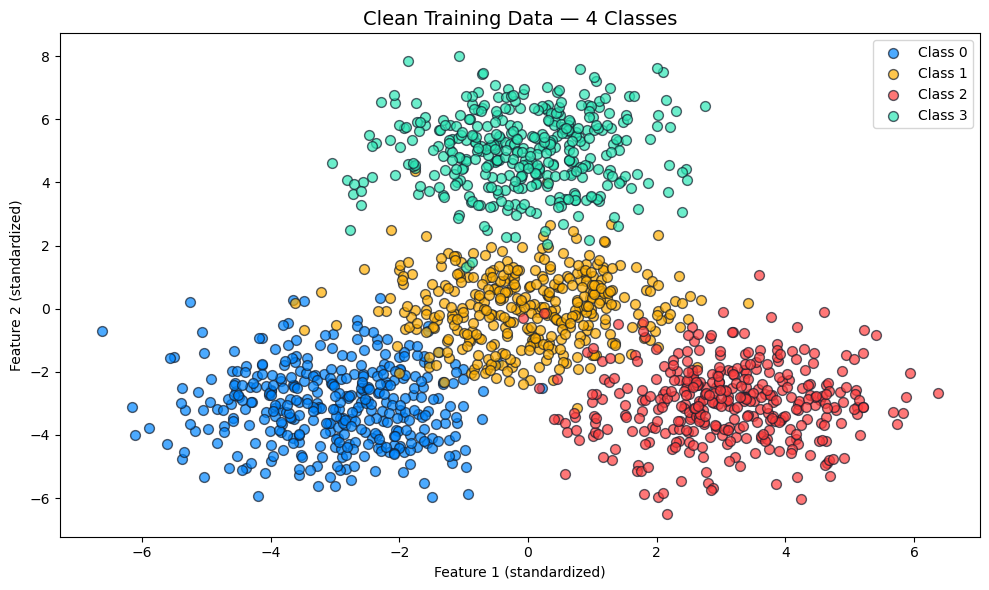

In [3]:
def plot_dataset(X, y, title):
    """Scatter plot of a 2D dataset colored by class label."""
    colors = ["#0086ff", "#ffaf00", "#ff3e3e", "#2ee7b6"]  # blue, yellow, red, cyan

    plt.figure(figsize=(10, 6))
    for cls in np.unique(y):
        mask = y == cls
        plt.scatter(X[mask, 0], X[mask, 1],
                    c=colors[int(cls)], label=f"Class {int(cls)}",
                    edgecolors="#141d2b", s=50, alpha=0.7)
    plt.title(title, fontsize=14)
    plt.xlabel("Feature 1 (standardized)")
    plt.ylabel("Feature 2 (standardized)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_dataset(X_train, y_train, "Clean Training Data — 4 Classes")

## 4. Train a Baseline Model (Before Attack)

We first train a clean model to establish what normal performance looks like.

Pay attention to **Class 1 recall** in the classification report - that's what our attack targets.

📸 **Screenshot tip:** Screenshot the classification report - specifically the Class 1 row. This is your baseline to compare against after poisoning.

In [4]:
baseline_model = OneVsRestClassifier(
    LogisticRegression(random_state=SEED, C=1.0, solver="lbfgs", max_iter=1000)
)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
baseline_acc    = accuracy_score(y_test, y_pred_baseline)

print("=== Baseline Model (Clean Data) ===")
print(f"Overall test accuracy: {baseline_acc:.4f}")
print()
print(classification_report(
    y_test, y_pred_baseline,
    target_names=[f"Class {i}" for i in range(4)],
    zero_division=0
))

=== Baseline Model (Clean Data) ===
Overall test accuracy: 0.9420

              precision    recall  f1-score   support

     Class 0       0.94      0.98      0.96       125
     Class 1       0.95      0.81      0.87       125
     Class 2       0.92      0.98      0.95       125
     Class 3       0.95      0.99      0.97       125

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



## 5. The Label Flipping Attack

### Strategy

We flip 80% of Class 1 training labels — half to Class 0, half to Class 2.

We keep 20% as Class 1 so the model still trains as a 4-class classifier. If we flipped all Class 1 labels, the model would only see 3 classes during training and fail at evaluation.

```
Class 1 training samples (100%)
    ├── 20% → kept as Class 1
    ├── 40% → flipped to Class 0
    └── 40% → flipped to Class 2
```

### Why this creates ambiguity

The OvR classifier trains one binary classifier per class. The "Class 1 vs rest" classifier now sees:
- Real Class 1 points labeled as Class 0 → pushes boundary in the wrong direction
- Real Class 1 points labeled as Class 2 → pushes it the other wrong direction
- Only a small fraction correctly labeled as Class 1

The result: at test time, the model has no reliable boundary for Class 1 and misclassifies it as either Class 0 or Class 2.

In [5]:
def label_flipping_attack(X_train_orig, y_train_orig, target_class,
                           flip_rate, seed):
    """
    Targeted label flipping attack against a specific class.

    Flips a fraction of target_class samples to neighboring classes,
    creating ambiguity at the decision boundary without affecting
    the accuracy of other classes.

    Parameters
    ----------
    X_train_orig : original feature matrix (unchanged)
    y_train_orig : original label array
    target_class : the class to attack (its labels will be flipped)
    flip_rate    : fraction of target class samples to flip (0.0 - 1.0)
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned       : label array with flipped labels
    flipped_indices  : indices of the modified samples
    """
    np.random.seed(seed)
    y_poisoned = y_train_orig.copy()

    # Find all samples belonging to the target class
    target_indices = np.where(y_train_orig == target_class)[0]

    # Shuffle so the selection is random
    np.random.shuffle(target_indices)

    # Keep a fraction as the original class so the model
    # still trains as a 4-class classifier
    keep_count   = int(len(target_indices) * (1 - flip_rate))
    to_flip      = target_indices[keep_count:]

    # Split evenly: half to class below, half to class above
    # This pushes the decision boundary from both sides simultaneously
    half         = len(to_flip) // 2
    flip_to_low  = to_flip[:half]           # flip to class below target
    flip_to_high = to_flip[half:]           # flip to class above target

    y_poisoned[flip_to_low]  = target_class - 1
    y_poisoned[flip_to_high] = target_class + 1

    flipped_indices = to_flip

    print(f"Attack summary:")
    print(f"  Target class          : {target_class}")
    print(f"  Total target samples  : {len(target_indices)}")
    print(f"  Kept as Class {target_class}       : {keep_count}")
    print(f"  Flipped to Class {target_class-1}    : {len(flip_to_low)}")
    print(f"  Flipped to Class {target_class+1}    : {len(flip_to_high)}")

    return y_poisoned, flipped_indices


# Run the attack targeting Class 1
y_train_poisoned, flipped_indices = label_flipping_attack(
    X_train, y_train,
    target_class=1,
    flip_rate=FLIP_RATE,
    seed=SEED
)

print(f"\nLabel distribution before: {np.bincount(y_train)}")
print(f"Label distribution after : {np.bincount(y_train_poisoned)}")

Attack summary:
  Target class          : 1
  Total target samples  : 375
  Kept as Class 1       : 74
  Flipped to Class 0    : 150
  Flipped to Class 2    : 151

Label distribution before: [375 375 375 375]
Label distribution after : [525  74 526 375]


## 6. Visualize the Poisoned Data

The poisoned dataset looks almost identical to the clean one — the data points haven't moved, only their labels changed.

Notice that the Class 1 region (orange) has shrunk significantly, with many of those points now labeled as Class 0 (blue) or Class 2 (red).

📸 **Screenshot tip:** Screenshot this plot side by side with the clean plot from Section 3 — the visual difference in Class 1 density tells the story clearly.

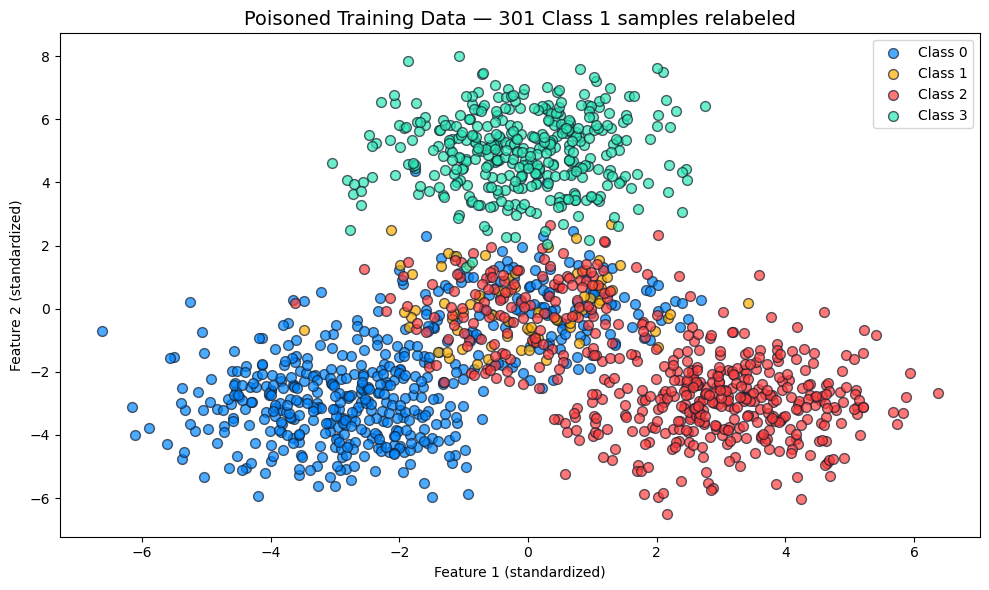

In [6]:
plot_dataset(
    X_train, y_train_poisoned,
    title=f"Poisoned Training Data — {len(flipped_indices)} Class 1 samples relabeled"
)

## 7. Train the Poisoned Model and Evaluate

We train a new model using the exact same architecture on the poisoned data.

A successful attack means:
- **Class 1 recall drops significantly** — the model misclassifies most Class 1 test samples
- **Classes 0, 2, 3 remain accurate** — the attack is targeted and stealthy
- **Overall accuracy stays relatively high** — nothing looks obviously wrong

📸 **Screenshot tip:** Screenshot both classification reports side by side — the drop in Class 1 recall is the key result. This is your proof of concept.

In [7]:
poisoned_model = OneVsRestClassifier(
    LogisticRegression(random_state=SEED, C=1.0, solver="lbfgs", max_iter=1000)
)
poisoned_model.fit(X_train, y_train_poisoned)

y_pred_poisoned = poisoned_model.predict(X_test)
poisoned_acc    = accuracy_score(y_test, y_pred_poisoned)

print("=== Poisoned Model Results ===")
print(f"Overall test accuracy: {poisoned_acc:.4f} (baseline was {baseline_acc:.4f})")
print()
print(classification_report(
    y_test, y_pred_poisoned,
    target_names=[f"Class {i}" for i in range(4)],
    zero_division=0
))

# Extract Class 1 recall specifically
from sklearn.metrics import recall_score
class1_recall_baseline = recall_score(y_test, y_pred_baseline, labels=[1], average="macro")
class1_recall_poisoned = recall_score(y_test, y_pred_poisoned, labels=[1], average="macro")

print(f"Class 1 recall — baseline : {class1_recall_baseline:.4f}")
print(f"Class 1 recall — poisoned : {class1_recall_poisoned:.4f}")
print(f"Recall drop               : {class1_recall_baseline - class1_recall_poisoned:.4f}")

if class1_recall_poisoned < 0.5:
    print("\n Attack SUCCESSFUL — Class 1 recall degraded significantly")
else:
    print("\n Attack insufficient — try increasing FLIP_RATE")

=== Poisoned Model Results ===
Overall test accuracy: 0.7440 (baseline was 0.9420)

              precision    recall  f1-score   support

     Class 0       0.70      1.00      0.83       125
     Class 1       0.00      0.00      0.00       125
     Class 2       0.65      0.99      0.78       125
     Class 3       0.94      0.98      0.96       125

    accuracy                           0.74       500
   macro avg       0.57      0.74      0.64       500
weighted avg       0.57      0.74      0.64       500

Class 1 recall — baseline : 0.8080
Class 1 recall — poisoned : 0.0000
Recall drop               : 0.8080

 Attack SUCCESSFUL — Class 1 recall degraded significantly


## 8. Key Takeaways

| Aspect | Detail |
|--------|--------|
| **Attack type** | Targeted label flipping |
| **Target** | Class 1 only |
| **Flip rate** | 80% of Class 1 samples relabeled |
| **Split** | 50% flipped to Class 0, 50% flipped to Class 2 |
| **Model** | 4-class One-vs-Rest Logistic Regression |
| **Detection difficulty** | Medium — overall accuracy stays high, only Class 1 degrades |

---

### Why Keep 20% of Class 1 Labels?

If all Class 1 labels are flipped, the training set has zero Class 1 samples. The model trains as a 3-class classifier and fails at evaluation. Keeping a small fraction ensures the model architecture stays correct while the attack still degrades Class 1 performance.

---

### Real-World Implications

This type of attack is particularly dangerous in systems where:
- Training data is collected from multiple sources or crowdsourced
- One specific class represents a high-value target (e.g. fraud detection, medical diagnosis, intrusion detection)
- Overall model accuracy is used as the sole health metric — targeted degradation of one class goes unnoticed

### Defenses

- **Per-class performance monitoring** — track recall per class, not just overall accuracy
- **Label auditing** — inspect label consistency across similar data points
- **Confident learning** — automatically identify likely mislabeled samples before training
- **Data provenance** — track the source of every training label
- **Ensemble disagreement** — train multiple models; if they disagree on a class, investigate

---

### References

- [MITRE ATLAS — Poison Training Data](https://atlas.mitre.org/techniques/AML.T0020)
- [OWASP Machine Learning Security Top 10](https://owasp.org/www-project-machine-learning-security-top-10/)
- [Confident Learning — Northcutt et al.](https://arxiv.org/abs/1911.00068)